# 🚀 Imports

In [70]:
# Maths
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# String
import urllib
import tldextract
import re

# Misc
import sys

def print_safe(url):
    '''Prints safe, unclickable URL in VS Code.'''
    sys.stdout.write(url.replace("://", "://\x00"))  # Null byte
    
# Number of CPU cores
# !lscpu

# ❗ IMPORTANT: SAFETY GUIDELINES AGAINST LINKS ⚠️

> ***READ BEFORE RUNNING ANY CELL***
>
> **The `url` column is dangerous if click link**, be careful. Other columns from are safe.
> - ⚠️ Display `df` — Always use `display(df)` so that URL are  not clickable.
> - ⚠️ Use `print_safe` — Use `print_safe(url)` so that URL are  not clickable.
> - ⚠️ String Parsing — Safe but make sure not to accidentally click link
>   - `urlparse`— Splits URL by structure
>   - `tldextract`— Splits domain specifically
>   - `re` — Finds patterns in string
> - ❌ DNS/WHOIS lookups — use `safe_dns_lookup()` only, one person runs this
> - ❌ `requests.get(url)` — never, under any circumstance


In [71]:
url = "http://mail.paypa1-secure.evil.com/login?user=1%20x"

# urlparse
from urllib.parse import urlparse
p = urlparse(url)
p.scheme    # 'http'
p.netloc    # 'mail.paypa1-secure.evil.com'
p.path      # '/login'
p.query     # 'user=1%20x'

# tldextract
ext = tldextract.extract(url)
ext.subdomain  # 'mail.paypa1-secure'
ext.domain     # 'evil'
ext.suffix     # 'com'

# re
re.search(r'\d+\.\d+\.\d+\.\d+', url)  # IP address present?
re.findall(r'\d', url)                 # digits in URL
re.search(r'%[0-9a-fA-F]{2}', url)     # hex encoding present?

print_safe(url)

http:// mail.paypa1-secure.evil.com/login?user=1%20x

---

# 🧪  Import Data

In [72]:
# Link to CSV
file_path = "../data/dataset-phishing.csv"
df = pd.read_csv(file_path)

# Move all columns with strings to the left
foo = ['url', 'dom', 'tld', 'url_len', 'dom_len', 'tld_len']
cols = foo + [col for col in df.columns if col not in foo]
df = df.reindex(columns=cols)
df.head()

,url,dom,tld,url_len,dom_len,tld_len,is_ip,subdom_cnt,letter_cnt,digit_cnt,...,under_cnt,letter_ratio,digit_ratio,spec_ratio,is_https,slash_cnt,entropy,path_len,query_len,label
0,https://www.rmit.edu.au/,rmit.edu.au,edu.au,24,11,6,0,1,17,0,...,0,0.708333,0.0,0.291667,1,3,3.709148,1,0,0
1,http://www.latrobe.edu.au/,latrobe.edu.au,edu.au,26,14,6,0,1,19,0,...,0,0.730769,0.0,0.269231,0,3,3.738149,1,0,0
2,https://www.cqu.edu.au/,cqu.edu.au,edu.au,23,10,6,0,1,16,0,...,0,0.695652,0.0,0.304348,1,3,3.609668,1,0,0
3,http://bond.edu.au/,bond.edu.au,edu.au,19,11,6,0,0,13,0,...,0,0.684211,0.0,0.315789,0,3,3.576618,1,0,0
4,http://www.csu.edu.au/,csu.edu.au,edu.au,22,10,6,0,1,15,0,...,0,0.681818,0.0,0.318182,0,3,3.503998,1,0,0


---

# 🧹 1. Data Cleaning

## 🔍 1.1 Initial Data Inspection

It was found that `NaN` values only appear in the `tld` column which is not used in the final dataframe.

In [73]:
# Create clean copy of original dataset
df_clean = df.copy()
print("Initial Data Inspection\n" + "-" * 23)

# 1. Shape of dataset
print(f"1. Original Shape: {df_clean.shape}")

# 2. NaN values
print(f"2. NaN Values: {df_clean.isnull().sum().sum()}")
print(f"    - url: {df_clean['url'].isnull().sum()}")
print(f"    - dom: {df_clean['dom'].isnull().sum()}")
print(f"    - tld: {df_clean['tld'].isnull().sum()}")
# --- More info on 'tld' values ---
# display(df_clean[df_clean.isnull().any(axis=1)])

# 3. Negative values (ignored first 3 str columns)
print(f"3. Negative Values: {(df_clean.iloc[:,3:] < 0).sum().sum()}")

# 4. Remove duplicate URLs
duplicate_urls = df_clean.duplicated(subset=['url'])
print(f"4. Duplicate URLs: {duplicate_urls.sum()}")
# --- View Duplicate URLs ---
# bar = df_clean[duplicate_urls]['url'].value_counts().to_dict()
# print(bar) # WARNING: display makes URL clicable

# 5. Verify 'label' column
legit_count = df_clean[df_clean['label'] == 0].shape[0]
phish_count = df_clean[df_clean['label'] == 1].shape[0]
total_count = legit_count + phish_count
print(f"5. Label Column (Legitimate + Phishing): {legit_count + phish_count}")
print(f"    - Legitimate: {legit_count} ({legit_count/total_count:.2%})")
print(f"    - Phishing: {phish_count} ({phish_count/total_count:.2%})")
# --- More info on `label` column ---
# display(df_clean['labbel'].value_counts())

print("-" * 23)

Initial Data Inspection
-----------------------
1. Original Shape: (116600, 26)
2. NaN Values: 14
    - url: 0
    - dom: 0
    - tld: 14
3. Negative Values: 0
4. Duplicate URLs: 1369
5. Label Column (Legitimate + Phishing): 116600
    - Legitimate: 100000 (85.76%)
    - Phishing: 16600 (14.24%)
-----------------------


## 🩹 1.2 Patch Errors in Data

Since only duplicates exist within the dataset, the following will be carried out:
1. **Deletion** of rows that have duplicate `url`.

In [ ]:
# Create clean copy of original dataset
df_clean = df.copy()
print("Initial Data Inspection\n" + "-" * 23)

# 1. No patch needed

# 2. No patch needed

# 3. No patch needed

# 4. Remove duplicate URLs
print(f"Removing {duplicate_urls.sum()} duplicate URLs...")
df_clean = df_clean.drop_duplicates(subset=['url'])
duplicate_urls = df_clean.duplicated(subset=['url'])
print(f"4. Duplicate URLs: {duplicate_urls.sum()}")
# --- View Duplicate URLs ---
# bar = df_clean[duplicate_urls]['url'].value_counts().to_dict()
# print(bar) # WARNING: display makes URL clicable

# 5. Verify 'label' column
legit_count = df_clean[df_clean['label'] == 0].shape[0]
phish_count = df_clean[df_clean['label'] == 1].shape[0]
total_count = legit_count + phish_count
print(f"5. Label Column (Legitimate + Phishing): {legit_count + phish_count}")
print(f"    - Legitimate: {legit_count} ({legit_count/total_count:.2%})")
print(f"    - Phishing: {phish_count} ({phish_count/total_count:.2%})")
# --- More info on `label` column ---
# display(df_clean['label'].value_counts())

print("-" * 23)

Initial Data Inspection
-----------------------
Removing 1369 duplicate URLs...
4. Duplicate URLs: 0
5. Label Column (Legitimate + Phishing): 115231
    - Legitimate: 98641 (85.60%)
    - Phishing: 16590 (14.40%)
-----------------------


---

# 🗺️ 2. EDA

We categorise the 22 features into the following groups so that our analysis is easier.

| Group              | Features                                                                 | What to look for                                      |
|--------------------|--------------------------------------------------------------------------|-------------------------------------------------------|
| Length-based (5)       | `url_len`, `dom_len`, `tld_len`, `path_len`, `query_len`                | Phishing URLs tend to be longer                      |
| Count-based (11)       | `letter_cnt`, `digit_cnt`, `special_cnt`, `eq_cnt`, `qm_cnt`, `amp_cnt`, `dot_cnt`, `dash_cnt`, `under_cnt`, `slash_cnt`, `subdom_cnt` | Abnormal counts signal obfuscation                   |
| Ratio-based (3)       | `letter_ratio`, `digit_ratio`, `spec_ratio`                             | Ratios normalize for URL length — more stable signals |
| Structural / binary (2)| `is_ip`, `is_https`                                                     | Binary — use value counts + label split              |
| Entropy (1)            | `entropy`                                                               | High entropy = random-looking, a strong phishing signal  |

In [ ]:
# Remove columns with strings for numerical analysis
df_filter = df_clean.copy()
df_filter = df_filter.iloc[:,3:]
df_filter.head()

,url_len,dom_len,tld_len,is_ip,subdom_cnt,letter_cnt,digit_cnt,special_cnt,eq_cnt,qm_cnt,...,under_cnt,letter_ratio,digit_ratio,spec_ratio,is_https,slash_cnt,entropy,path_len,query_len,label
0,24,11,6,0,1,17,0,7,0,0,...,0,0.708333,0.0,0.291667,1,3,3.709148,1,0,0
1,26,14,6,0,1,19,0,7,0,0,...,0,0.730769,0.0,0.269231,0,3,3.738149,1,0,0
2,23,10,6,0,1,16,0,7,0,0,...,0,0.695652,0.0,0.304348,1,3,3.609668,1,0,0
3,19,11,6,0,0,13,0,6,0,0,...,0,0.684211,0.0,0.315789,0,3,3.576618,1,0,0
4,22,10,6,0,1,15,0,7,0,0,...,0,0.681818,0.0,0.318182,0,3,3.503998,1,0,0


## 📉 Redundant Feature Check (Correlation Matrix) ✅

Further analysis in the following sections will determine which features to be dropped.
- Normally two features such as `url_len` and `letter_ratio` have high correlation because one is a subset on the other.
- We cannot simply remove either one of the features because their meaning meaning has transformed somewhat.
- To determine whether to keep or remove such features, need to investigate using statistics or plotting relavant graphs.



In [76]:
from sklearn.ensemble import RandomForestClassifier

# Calculate correlations with target variable 'label'
correlations = df_filter.corr(numeric_only=True)['label'].abs().sort_values(ascending=False)

# Random forest feature importance
X = df_filter.drop(columns=['label'])
y = df_filter['label']
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X, y)
rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Combine into one DataFrame - DROP 'label' from correlations FIRST
correlations_without_label = correlations.drop('label')

# Now all columns have the same index
comparison_table = pd.DataFrame({
    'Feature': correlations_without_label.index,
    'Correlation coefficient': correlations_without_label.values,
    'RF_Importance (Normalised)': rf_importance.reindex(correlations_without_label.index).values
})

print("\nFeature Importance Comparison")
print("-" * 65)
print(comparison_table.to_string(index=False))
print("-" * 65)


Feature Importance Comparison
-----------------------------------------------------------------
     Feature  Correlation coefficient  RF_Importance (Normalised)
 digit_ratio                 0.517661                    0.108146
     entropy                 0.513368                    0.136374
    is_https                 0.400466                    0.153889
  spec_ratio                 0.385275                    0.053586
   digit_cnt                 0.329212                    0.065007
     url_len                 0.323547                    0.056323
  letter_cnt                 0.300636                    0.047336
      eq_cnt                 0.261119                    0.001772
    path_len                 0.249139                    0.071624
    dash_cnt                 0.247773                    0.032228
      qm_cnt                 0.225656                    0.000858
     amp_cnt                 0.224631                    0.000456
 special_cnt                 0.203040        

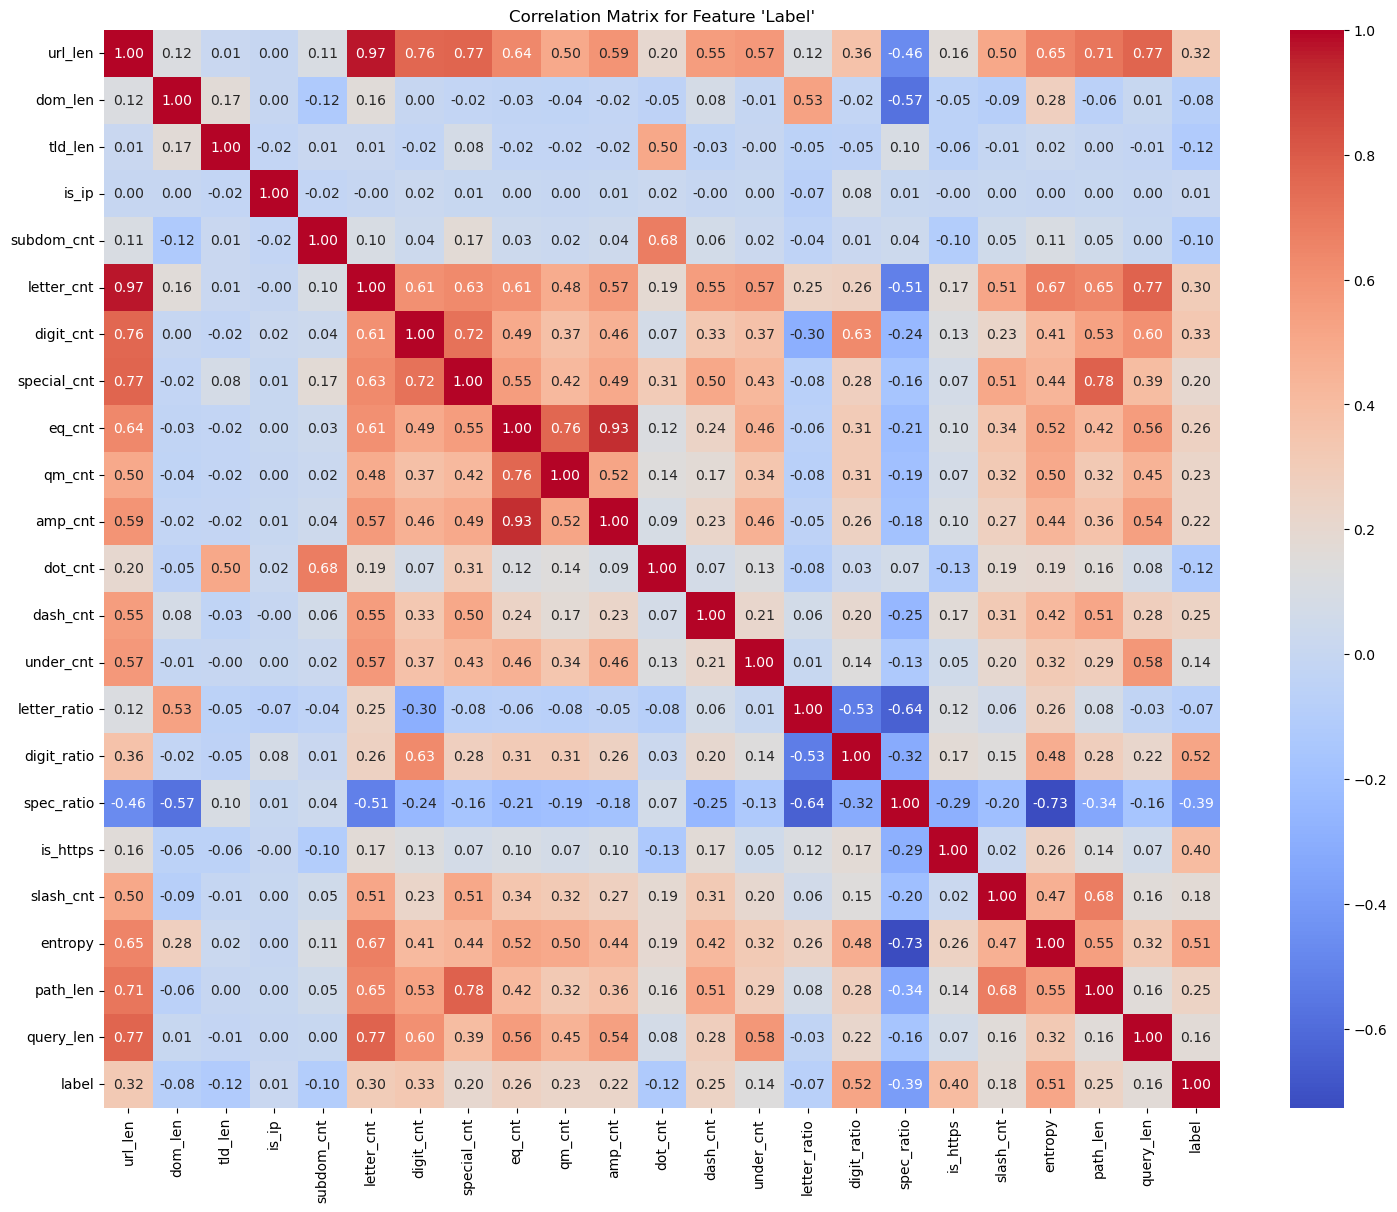

In [77]:
# Plot correlation heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(df_filter.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix for Feature 'Label'")
plt.show()

- Use Random forest to visualise important features and compare with correlation.

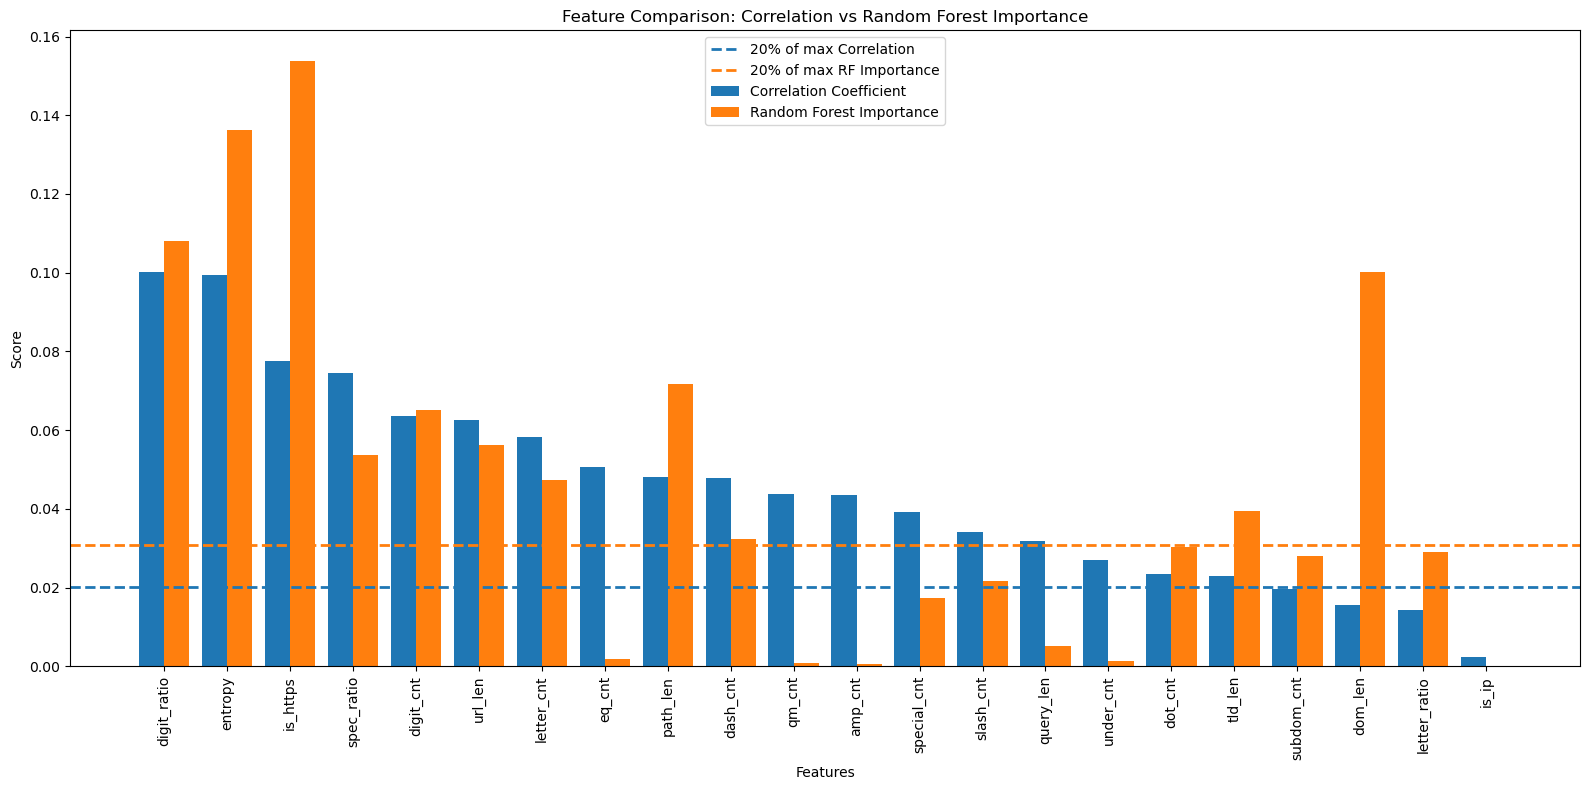

In [78]:
# Remove target itself from correlation list
correlations_without_label = correlations.drop('label')

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Feature': correlations_without_label.index,
    'Correlation_Normalised': correlations_without_label.values / correlations_without_label.sum(),
    'RF_Importance': rf_importance.reindex(correlations_without_label.index).fillna(0).values
})

# Plot
plt.figure(figsize=(16,8))
bar_width = 0.4
indices = np.arange(len(comparison_df))

# Bar graph
plt.bar(indices - bar_width/2, comparison_df['Correlation_Normalised'], width=bar_width, label='Correlation Coefficient')
plt.bar(indices + bar_width/2, comparison_df['RF_Importance'], width=bar_width, label='Random Forest Importance')

# Dotted horizontal line (20% of maximum feature importance)
threshold_co = comparison_df['Correlation_Normalised'].max() * 0.2
threshold_rf = comparison_df['RF_Importance'].max() * 0.2

plt.axhline(y=threshold_co, color='C0', linestyle='--', linewidth=2, label='20% of max Correlation')
plt.axhline(y=threshold_rf, color='C1', linestyle='--', linewidth=2, label='20% of max RF Importance')

plt.xticks(indices, comparison_df['Feature'], rotation=90)
plt.xlabel('Features')
plt.ylabel('Score')
plt.title('Feature Comparison: Correlation vs Random Forest Importance')
plt.legend(loc='upper center')
plt.tight_layout()
plt.show()

## 📏 2.1 Length-Based

It was found that

In [ ]:
# Create df with only length features
features_len = ['url_len', 'dom_len', 'tld_len', 'path_len', 'query_len', 'label']
df_len = df_filter[features_len]
df_len.head()

,url_len,dom_len,tld_len,path_len,query_len,label
0,24,11,6,1,0,0
1,26,14,6,1,0,0
2,23,10,6,1,0,0
3,19,11,6,1,0,0
4,22,10,6,1,0,0


## 🧮 2.2 Count-Based

In [ ]:
# Create df with only count features
features_cnt = ['letter_cnt', 'digit_cnt', 'special_cnt', 'eq_cnt', 'qm_cnt', 'amp_cnt', 
                  'dot_cnt', 'dash_cnt', 'under_cnt', 'slash_cnt', 'subdom_cnt', 'label']
df_cnt = df_filter[features_cnt]
df_cnt.head()

,letter_cnt,digit_cnt,special_cnt,eq_cnt,qm_cnt,amp_cnt,dot_cnt,dash_cnt,under_cnt,slash_cnt,subdom_cnt,label
0,17,0,7,0,0,0,3,0,0,3,1,0
1,19,0,7,0,0,0,3,0,0,3,1,0
2,16,0,7,0,0,0,3,0,0,3,1,0
3,13,0,6,0,0,0,2,0,0,3,0,0
4,15,0,7,0,0,0,3,0,0,3,1,0


## ➗ 2.3 Ratio-Based

In [81]:
# Create df with only ratio features
features_ratio = ['letter_ratio', 'digit_ratio', 'spec_ratio', 'label']
df_ratio = df_filter[features_ratio]
df_ratio.head()

,letter_ratio,digit_ratio,spec_ratio,label
0,0.708333,0.0,0.291667,0
1,0.730769,0.0,0.269231,0
2,0.695652,0.0,0.304348,0
3,0.684211,0.0,0.315789,0
4,0.681818,0.0,0.318182,0


## ⭕ 2.4 Structural / Binary

In [83]:
# Create df with only binary features
features_binary = ['is_ip', 'is_https', 'label']
df_binary = df_filter[features_binary]
df_binary.head()

,is_ip,is_https,label
0,0,1,0
1,0,0,0
2,0,1,0
3,0,0,0
4,0,0,0


## 🌡️ 2.5. Shanon Entropy

In [84]:
# Create df with only entropy feature
features_entropy = ['entropy', 'label']
df_entropy = df_filter[features_entropy]
df_entropy.head()

,entropy,label
0,3.709148,0
1,3.738149,0
2,3.609668,0
3,3.576618,0
4,3.503998,0


### Theory

Given a discrete random variable $X$ over an alphabet $\mathcal{A}$ with probability mass function $P(X=x_i)=p_i$, the **Shanon entropy** is:
$$
H(X)=-\sum_{i=1}^n p_i\log_2p_i
$$

For a string $s$ of length $N$ over alphabet $\mathcal{A}$, the formula for probability $p_i$ of seeing character $c_i$ is:
$$
p_i=\frac{\mathrm{count}(c_i,s)}{N},\qquad \forall c_i\in\mathcal{A}
$$

Therefore, the full formula for Shanon entropy applied to a string is:
$$
H(s)=-\sum_{c_i\in\mathcal{A}}\frac{\mathrm{count}(c_i,s)}{N}\cdot \log_2\left(\frac{\mathrm{count}(c_i,s)}{N}\right)
$$

Invariant rule:
$$
0\leq H(s)\leq \log_2\left|\mathcal{A}\right|
$$

> Note that these are **empirical frequencies**, the string's character distribution is used as the probability model. Meaning, this is the most fundamental form of entropy that solely depends on the number of occurrences of a character within a particular string, it does NOT use the known probability of a character appearing in English langauge (i.e. Cross Entropy).